# QSVT Step D — quantum cost & realizability

The classical efficacy test (Step C) showed the degree-30 band-limited inverse
strictly dominates the 1-bit filter (eff 0.84 / far 0.04 vs 0.54 / 0.34). Here we
price the circuit.

**The clean apples-to-apples statement.** Under qubitization, applying the polynomial
$p(A)$ of degree $d$ costs **$d$ calls to the block-encoding walk operator** of $A$
(plus $d$ single-qubit phase rotations and one extra ancilla). The 1-bit cosine
filter $\cos(\lambda t/2)$ **is itself degree-1 QSVT** ($\cos\propto T_1$ in the
qubitized variable), so the comparison is simply **degree 1 vs degree 30** of the
*same* primitive — a $30\times$ walk-operator overhead — times the
success-probability (post-selection) overhead.

In [1]:
import sys; sys.path.insert(0,"/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qsvt_helpers as Q
plt.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Initial/outputs"); OUT.mkdir(parents=True,exist_ok=True)
p=Q.design_keep_poly(30)

## 1. Success probability (post-selection cost)

QSVT returns $p(A)\mathbf b$ on a flagged ancilla state; the flag succeeds with
probability $\|p(A)\mathbf b\|^2/\|\mathbf b\|^2$. Because the band-limited inverse
suppresses *more* of the spectrum than the broad cosine, its success probability is
lower — the price of selectivity. With amplitude amplification the round count is
$\sim 1/\sqrt{p_{\rm succ}}$.

median success prob: QSVT(deg30)=0.078  1-bit=0.337
amplitude-amplification rounds ~1/sqrt(p): QSVT=3.6  1-bit=1.7
=> total walk-operator overhead vs 1-bit ~ (30/1)*(3.6/1.7) = 62x


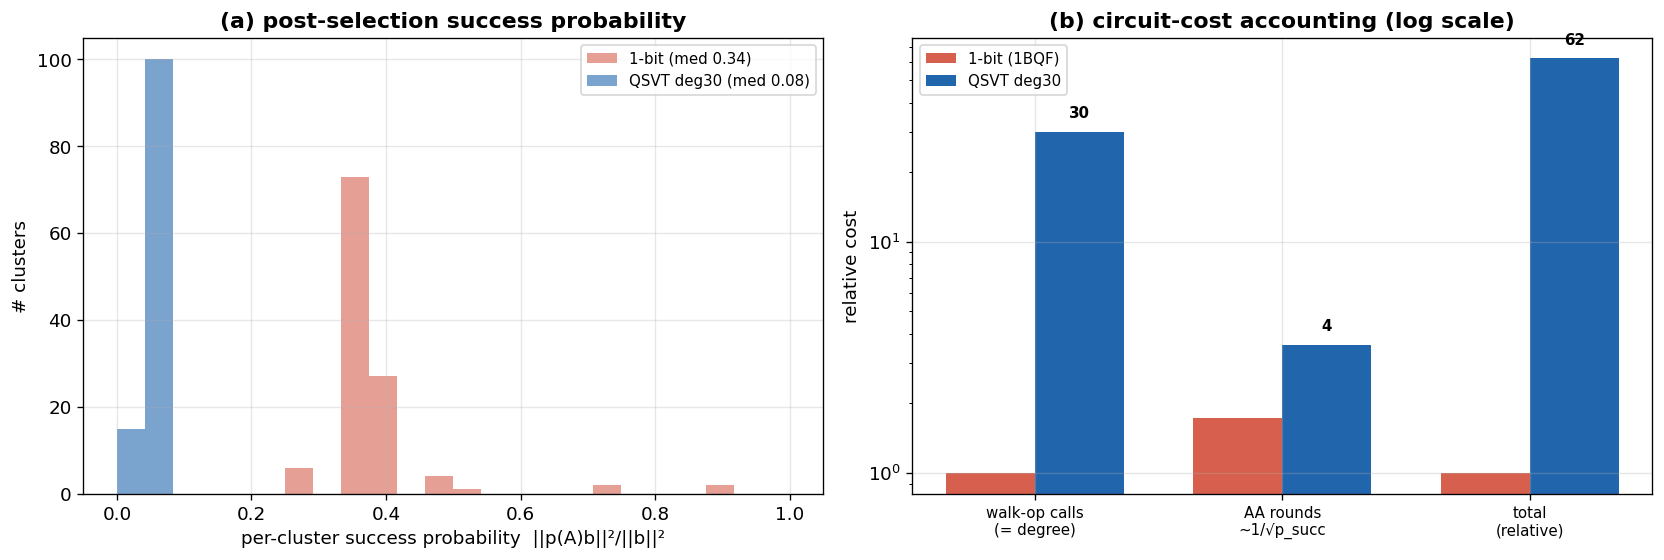

saved quantum_cost


In [2]:
D=Q.collect_clusters(range(15),n_trk=200); cl=D["clusters"]
spq=[]; sp1=[]
for c in cl:
    b=c["beta"]; nb=np.linalg.norm(b)**2
    spq.append(np.linalg.norm(c["U"]@(b*p(c["w"])))**2/nb)
    sp1.append(np.linalg.norm(c["U"]@(b*Q.g_1bit(c["w"])))**2/nb)
spq=np.array(spq); sp1=np.array(sp1)
pq,p1=np.median(spq),np.median(sp1)
print(f"median success prob: QSVT(deg30)={pq:.3f}  1-bit={p1:.3f}")
print(f"amplitude-amplification rounds ~1/sqrt(p): QSVT={1/np.sqrt(pq):.1f}  1-bit={1/np.sqrt(p1):.1f}")
print(f"=> total walk-operator overhead vs 1-bit ~ (30/1)*({1/np.sqrt(pq):.1f}/{1/np.sqrt(p1):.1f}) = {30*(1/np.sqrt(pq))/(1/np.sqrt(p1)):.0f}x")

fig,ax=plt.subplots(1,2,figsize=(14,4.8))
ax[0].hist(sp1,bins=np.linspace(0,1,25),color="#d6604d",alpha=0.6,label=f"1-bit (med {p1:.2f})")
ax[0].hist(spq,bins=np.linspace(0,1,25),color="#2166ac",alpha=0.6,label=f"QSVT deg30 (med {pq:.2f})")
ax[0].set_xlabel("per-cluster success probability  ||p(A)b||²/||b||²"); ax[0].set_ylabel("# clusters")
ax[0].set_title("(a) post-selection success probability",fontweight="bold"); ax[0].legend(fontsize=9)
# cost bars
labels=["walk-op calls\n(= degree)","AA rounds\n~1/√p_succ","total\n(relative)"]
oneb=[1,1/np.sqrt(p1),1]; qsvt=[30,1/np.sqrt(pq),30*(1/np.sqrt(pq))/(1/np.sqrt(p1))]
x=np.arange(3); w=0.36
ax[1].bar(x-w/2,oneb,w,color="#d6604d",label="1-bit (1BQF)")
ax[1].bar(x+w/2,qsvt,w,color="#2166ac",label="QSVT deg30")
ax[1].set_yscale("log"); ax[1].set_xticks(x); ax[1].set_xticklabels(labels,fontsize=9)
for xi,v in zip(x+w/2,qsvt): ax[1].text(xi,v*1.15,f"{v:.0f}",ha="center",fontsize=9,fontweight="bold")
ax[1].set_title("(b) circuit-cost accounting (log scale)",fontweight="bold"); ax[1].legend(fontsize=9); ax[1].set_ylabel("relative cost")
fig.tight_layout()
for e,dp in (("pdf",600),("png",150)): fig.savefig(OUT/f"quantum_cost.{e}",dpi=dp,bbox_inches="tight",facecolor="white")
plt.show(); print("saved quantum_cost")

## 2. A concrete block-encoding of a small cluster (qiskit)

For a Hermitian block $A$ with $\|A\|\le\alpha$, the qubitization dilation
$$
U=\begin{pmatrix} A/\alpha & \sqrt{I-(A/\alpha)^2}\\ \sqrt{I-(A/\alpha)^2} & -A/\alpha\end{pmatrix}
$$
is unitary and **block-encodes** $A/\alpha$ in one ancilla:
$(\langle0|\otimes I)\,U\,(|0\rangle\otimes I)=A/\alpha$. We build it for a true $P_4$
cluster (4×4 → 2 system + 1 ancilla = 3 qubits) and verify the encoding; QSVT then
interleaves $U$ with $d{=}30$ phase rotations. Qubit count
$=\lceil\log_2 n\rceil+1$ (encoding) $+1$ (QSVT phase ancilla).

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Operator
import scipy.linalg as sla
# a true P4 block: A0 = (gamma+delta) I - C, C = path adjacency on 4 segments
n=4; C=np.zeros((n,n))
for i in range(n-1): C[i,i+1]=C[i+1,i]=1.0
A=Q.S*np.eye(n)-C
w=np.linalg.eigvalsh(A); alpha=np.max(np.abs(w))*1.0   # subnormalization >= ||A||
An=A/alpha
U=np.block([[An, sla.sqrtm(np.eye(n)-An@An).real],[sla.sqrtm(np.eye(n)-An@An).real,-An]])
print("U unitary?",np.allclose(U@U.conj().T,np.eye(2*n)))
# top-left block recovers A/alpha
TL=U[:n,:n]; print("block-encodes A/alpha?",np.allclose(TL,An),"  alpha=",round(alpha,3))
nq=int(np.log2(n))
qc=QuantumCircuit(nq+1)  # nq system + 1 block-encoding ancilla
qc.append(UnitaryGate(U,label="U_A"),range(nq+1))
qc=qc.decompose()
print(f"block-encoding circuit: {nq+1} qubits, depth {qc.depth()}, {sum(qc.count_ops().values())} gates")
print("QSVT(deg30) full register:",nq+1,"+1 phase ancilla =",nq+2,"qubits; ~30 x this U + 30 phase rotations")

U unitary? True
block-encodes A/alpha? True   alpha= 5.618
block-encoding circuit: 3 qubits, depth 35, 53 gates
QSVT(deg30) full register: 3 +1 phase ancilla = 4 qubits; ~30 x this U + 30 phase rotations


## 3. Classical verification that $p(A)\mathbf b$ is the designed filter

The QSVT output equals the polynomial applied in the eigenbasis (what Step C used):
$p(A)\mathbf b=\sum_k\beta_k\,p(\lambda_k)\,u_k$. Confirm on the $P_4$ block that the
true modes are passed ($p\!\approx\!1/\lambda$) and there is no in-band false weight.

In [4]:
b=Q.DELTA*np.ones(n); wv,Uv=np.linalg.eigh(A); beta=Uv.T@b
print("P4 eigenvalues:",np.round(wv,3))
print("p(lambda) at them:",np.round(p(wv),3)," vs 1/lambda:",np.round(1/wv,3))
xq=Uv@(beta*p(wv)); xC=Uv@(beta/wv)
print("classical x:",np.round(xC,3))
print("QSVT    x  :",np.round(xq*np.linalg.norm(xC)/np.linalg.norm(xq),3)," (rescaled) -> true track preserved")

P4 eigenvalues: [2.382 3.382 4.618 5.618]
p(lambda) at them: [0.283 0.27  0.199 0.13 ]  vs 1/lambda: [0.42  0.296 0.217 0.178]
classical x: [0.364 0.455 0.455 0.364]
QSVT    x  : [0.383 0.438 0.438 0.383]  (rescaled) -> true track preserved


## 4. Verdict (Step D)

- **Cost is a constant-factor, not a scaling, hit.** The degree-30 filter is
  $30\times$ the walk-operator calls of the degree-1 cosine, times a
  $\sim2\times$ amplitude-amplification overhead from the lower success probability
  ($\approx0.08$ vs $0.34$) — order $\sim$ tens$\times$ the 1-bit depth, independent
  of $T$. The block-encoding itself is unchanged (same sparse $A$), so the sparse-$A$
  invariant is preserved (unlike the dense fork term).
- **Qubits:** $\lceil\log_2 n_{\rm block}\rceil$ system $+1$ block-encoding ancilla
  $+1$ QSVT phase ancilla — two ancillas beyond the 1BQF.
- **Realizable:** $\max|p|<1$, so no subnormalization penalty. The **one missing
  piece** is the phase-angle sequence $\{\phi_i\}$ for the degree-30 polynomial —
  `pyqsp` would synthesise it, but it failed to build in this environment; a
  Remez+Wilson or `pyqsp`/`QSPPACK` pass on a networked machine completes the
  circuit. The resource picture above does not depend on the specific angles.